# Clasificación de textos por década — Parte 1: Machine Learning Clásico

**Competencia:** Aprendizaje de Máquina 2026-10  
**Tarea:** Predecir la **década** (primeros 3 dígitos del año) en que fue escrito un párrafo de texto histórico en español.  
**Clases:** Décadas del `150` al `188` (años 1500–1889), **39 clases** en total.  
**Restricción:** Únicamente modelos de `scikit-learn`, sin redes neuronales ni transformers.

## 1. Importaciones

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report

try:
    from sklearn.experimental import enable_halving_search_cv  # noqa (sklearn < 1.0)
except ImportError:
    pass
from sklearn.model_selection import HalvingGridSearchCV

SEED = 42
np.random.seed(SEED)

## 2. Carga de datos

In [21]:
df_train = pd.read_csv('data/train.csv')
df_eval  = pd.read_csv('data/eval.csv')

print(f"Train: {df_train.shape}")
print(f"Eval:  {df_eval.shape}")
df_train.head(3)

Train: (31403, 2)
Eval:  (3490, 2)


,text,decade
0,\r\nHonorarias ¡jubiladas. 57 \r\ndit.ad Ponte...,164
1,"gone. Sus amigos , sus clientes, todo \r\ncuan...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157


## 3. Análisis Exploratorio (EDA)

Décadas únicas : 39
Rango          : 150 – 188
Ejemplos/clase : min=754, max=848, media=805


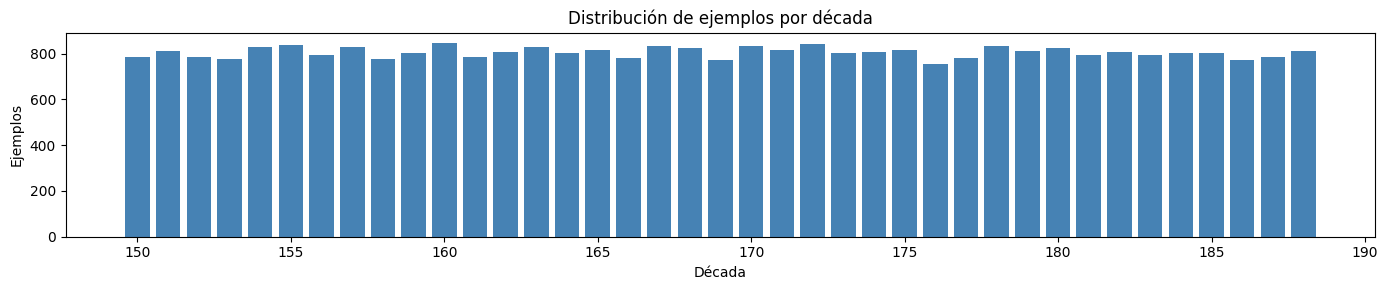

In [22]:
vc = df_train['decade'].value_counts().sort_index()

print(f"Décadas únicas : {df_train['decade'].nunique()}")
print(f"Rango          : {df_train['decade'].min()} – {df_train['decade'].max()}")
print(f"Ejemplos/clase : min={vc.min()}, max={vc.max()}, media={vc.mean():.0f}")

plt.figure(figsize=(14, 3))
plt.bar(vc.index, vc.values, color='steelblue')
plt.xlabel('Década'); plt.ylabel('Ejemplos')
plt.title('Distribución de ejemplos por década')
plt.tight_layout(); plt.show()

count    31403.000000
mean       530.087316
std        539.636593
min        120.000000
25%        185.000000
50%        321.000000
75%        655.000000
max       7480.000000
Name: text, dtype: float64


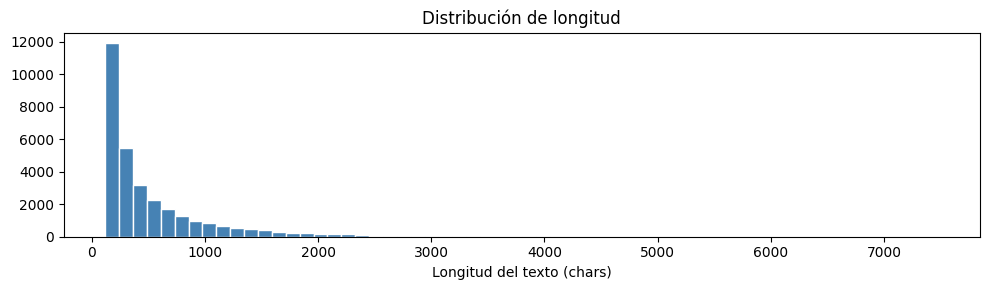

In [23]:
# Longitud de los textos
lens = df_train['text'].str.len()
print(lens.describe())

plt.figure(figsize=(10, 3))
plt.hist(lens, bins=60, color='steelblue', edgecolor='white')
plt.xlabel('Longitud del texto (chars)'); plt.title('Distribución de longitud')
plt.tight_layout(); plt.show()

In [24]:
# Muestra de textos por siglo
for decade in [150, 160, 170, 180, 188]:
    sample = df_train[df_train['decade'] == decade]['text'].iloc[0][:120]
    print(f"Década {decade}: {repr(sample)}\n")

Década 150: 'efiotnl fiiT’e^ pt\\»tf)e 4 trCe et lleene.^^ta^ \r\n41 tT»íi A*e(leee A(ittc(«t>iieii|l>le iié <oii|ette \r\n*iW íléiW^* tem'

Década 160: "blar enla oracion de pereza, i floxedad ,i por eltar medio: \r\ndormido», ifi hablara,fe defpertara,i'avivara para la orar"

Década 170: '\r\n2y. Mas fi no mieote el oido: \r\nReyna. Palos fuenan. Rey. Paños andan \r\nSalen por laswejimas puertas que fe entraromg '

Década 180: '\r\n(87) \r\nobligación  que  las  Ordenanzas  imponen  al  Director \r\ngeneral  de  la  Armada  sobre  el  zelar  que  se  m'

Década 188: '\r\n—  302  — \r\ncapaz  el  corazón  corrompido  del  hombre  inculto  é  iluso.  Y  no \r\ndeja  de  ser  digno  de  notarse'



## 4. Preprocesamiento del texto

Se aplica una limpieza **mínima** para preservar las señales ortográficas históricas que cambiaron entre los siglos XVI y XIX (e.g. uso de la 's' larga escrita como 'f', cambios en 'b/v', ortografía variante, etc.). Esas características son la clave para la clasificación temporal.

In [25]:
def preprocess(text: str) -> str:
    """Limpieza mínima: colapsa saltos de línea y convierte a minúsculas."""
    if not isinstance(text, str):
        return ''
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = text.lower()
    return re.sub(r' +', ' ', text).strip()

df_train['clean_text'] = df_train['text'].apply(preprocess)
df_eval['clean_text']  = df_eval['text'].apply(preprocess)

print("Original:")
print(repr(df_train['text'].iloc[0][:200]))
print("\nLimpio:")
print(repr(df_train['clean_text'].iloc[0][:200]))

Original:
'\r\nHonorarias ¡jubiladas. 57 \r\ndit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 \r\npag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len \r\nnes parece que aísilte, O ayuda Calsiodoro \r\nlib,6.epuft.s 2.Donde * l'

Limpio:
'honorarias ¡jubiladas. 57 dit.ad pontem de poreft.proreg.118,3, $.9.m.-70 pag.4.1. 3 ste ph.gratian. difcept.291, áqu len nes parece que aísilte, o ayuda calsiodoro lib,6.epuft.s 2.donde * llama oclos'


In [26]:
X_train = df_train['clean_text'].values
y_train = df_train['decade'].values
X_eval  = df_eval['clean_text'].values

print(f"Train: {len(X_train)} ejemplos | Eval: {len(X_eval)} ejemplos")

Train: 31403 ejemplos | Eval: 3490 ejemplos


## 5. Búsqueda de hiperparámetros con HalvingGridSearchCV

Se construye un **Pipeline híbrido** compuesto por:

- **`FeatureUnion`** que concatena dos matrices TF-IDF:
  - **Caracteres** `analyzer='char', ngram_range=(3,5), min_df=5` — captura ortografía histórica y patrones morfológicos.
  - **Palabras** `analyzer='word', ngram_range=(1,2), min_df=3, max_df=0.8` — captura vocabulario y contexto léxico de cada época.
- **`LogisticRegression(solver='saga')`** — mejor calibración multiclase en 39 clases con alta superposición.

Hiperparámetro a optimizar:

| Parámetro | Descripción | Valores |
|---|---|---|
| `clf__C` | Regularización inversa de LogisticRegression | 0.1, 1.0, 5.0 |

`HalvingGridSearchCV` descarta rápidamente las configuraciones malas usando sucesivamente más datos.

In [27]:
# División hold-out estratificada (85% train / 15% val)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train
)
print(f"Train: {len(X_tr)} | Val: {len(X_val)}")

Train: 26692 | Val: 4711


In [28]:
# Pipeline híbrido: FeatureUnion(char + word) + LogisticRegression(saga)
pipe = Pipeline([
    ('features', FeatureUnion([
        ('char', TfidfVectorizer(
            analyzer='char',
            ngram_range=(3, 5),
            sublinear_tf=True,
            min_df=5,
        )),
        ('word', TfidfVectorizer(
            analyzer='word',
            ngram_range=(1, 2),
            sublinear_tf=True,
            min_df=3,
            max_df=0.8,
        )),
    ])),
    ('clf', LogisticRegression(solver='saga', max_iter=200, n_jobs=-1, random_state=SEED))
])

param_grid = {
    'clf__C': [0.1, 1.0, 5.0],
}

search = HalvingGridSearchCV(
    pipe,
    param_grid,
    factor=3,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=SEED,
)

print(f"Grid: {param_grid}")
print(f"Combinaciones: {len(param_grid['clf__C'])} valores de C")

Grid: {'clf__C': [0.1, 1.0, 5.0]}
Combinaciones: 3 valores de C


In [29]:
print("Ejecutando HalvingGridSearchCV...")
search.fit(X_tr, y_tr)

print(f"\nMejores hiperparámetros : {search.best_params_}")
print(f"CV accuracy (mejor)     : {search.best_score_:.4f}")

val_acc = accuracy_score(y_val, search.predict(X_val))
print(f"Val accuracy (hold-out) : {val_acc:.4f}")
print(f"Baseline aleatorio      : {1/39:.4f}")

Ejecutando HalvingGridSearchCV...
n_iterations: 2
n_required_iterations: 2
n_possible_iterations: 2
min_resources_: 8897
max_resources_: 26692
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 3
n_resources: 8897
Fitting 5 folds for each of 3 candidates, totalling 15 fits
----------
iter: 1
n_candidates: 1
n_resources: 26691
Fitting 5 folds for each of 1 candidates, totalling 5 fits

Mejores hiperparámetros : {'clf__C': 5.0}
CV accuracy (mejor)     : 0.2615
Val accuracy (hold-out) : 0.2632
Baseline aleatorio      : 0.0256


In [30]:
# Top configuraciones evaluadas por HalvingGridSearchCV
cv_df = pd.DataFrame(search.cv_results_)
top = (cv_df
       .nlargest(5, 'mean_test_score')
       [['param_clf__C', 'mean_test_score', 'std_test_score']]
       .reset_index(drop=True))
print(top.to_string())
print(f"\nMejor: C={search.best_params_['clf__C']}")

   param_clf__C  mean_test_score  std_test_score
0           5.0         0.261476        0.006285
1           0.1              NaN             NaN
2           1.0              NaN             NaN
3           5.0              NaN             NaN

Mejor: C=5.0


## 6. Entrenamiento del modelo final

Se extraen los mejores hiperparámetros de `HalvingGridSearchCV` y se reentrena el pipeline híbrido con **todos los datos de entrenamiento** (train + val).

In [31]:
# Reentrenar con los mejores hiperparámetros sobre TODOS los datos
best_params = search.best_params_
print(f"Mejores parámetros: {best_params}")

best_pipeline = Pipeline([
    ('features', FeatureUnion([
        ('char', TfidfVectorizer(
            analyzer='char',
            ngram_range=(3, 5),
            sublinear_tf=True,
            min_df=5,
        )),
        ('word', TfidfVectorizer(
            analyzer='word',
            ngram_range=(1, 2),
            sublinear_tf=True,
            min_df=3,
            max_df=0.8,
        )),
    ])),
    ('clf', LogisticRegression(
        solver='saga',
        max_iter=200,
        n_jobs=-1,
        random_state=SEED,
        C=best_params['clf__C'],
    ))
])

print("Reentrenando sobre todos los datos de entrenamiento...")
best_pipeline.fit(X_train, y_train)

train_acc = accuracy_score(y_train, best_pipeline.predict(X_train))
print(f"Train accuracy (referencia) : {train_acc:.4f}")
print(f"Val   accuracy (hold-out)   : {val_acc:.4f}")

Mejores parámetros: {'clf__C': 5.0}
Reentrenando sobre todos los datos de entrenamiento...
Train accuracy (referencia) : 0.9991
Val   accuracy (hold-out)   : 0.2632


In [32]:
# Reporte de clasificación sobre el hold-out (pipeline entrenado en X_tr)
val_pred = search.predict(X_val)
print(classification_report(y_val, val_pred))

              precision    recall  f1-score   support

         150       0.84      0.75      0.79       118
         151       0.47      0.66      0.55       122
         152       0.66      0.53      0.59       118
         153       0.56      0.59      0.57       116
         154       0.47      0.59      0.52       125
         155       0.42      0.35      0.38       126
         156       0.38      0.37      0.37       119
         157       0.27      0.33      0.30       124
         158       0.24      0.27      0.26       117
         159       0.24      0.29      0.26       120
         160       0.12      0.13      0.12       127
         161       0.14      0.14      0.14       118
         162       0.17      0.17      0.17       121
         163       0.19      0.18      0.18       124
         164       0.20      0.17      0.18       121
         165       0.11      0.10      0.10       122
         166       0.12      0.08      0.09       117
         167       0.19    

## 7. Análisis de errores

Distribución de error (décadas de diferencia):
  |error| = 0:  26.3%
  |error| = 1:  17.5%
  |error| = 2:  12.9%
  |error| = 3:  9.6%
  |error| = 4:  7.3%
  |error| = 5:  5.5%
  |error| ≥ 6:  20.9%


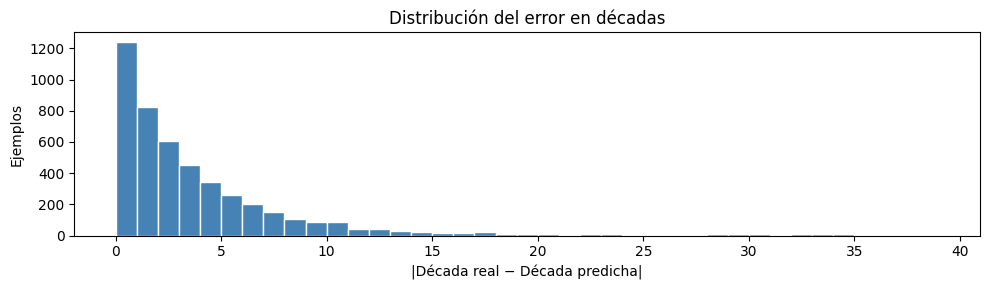

In [33]:
# ¿Cuánto se equivoca el modelo en número de décadas?
errors = np.abs(y_val.astype(int) - val_pred.astype(int))
print("Distribución de error (décadas de diferencia):")
for k in range(6):
    pct = (errors == k).mean() * 100
    print(f"  |error| = {k}:  {pct:.1f}%")
print(f"  |error| ≥ 6:  {(errors >= 6).mean()*100:.1f}%")

plt.figure(figsize=(10, 3))
plt.hist(errors, bins=range(0, 40), color='steelblue', edgecolor='white')
plt.xlabel('|Década real − Década predicha|')
plt.ylabel('Ejemplos'); plt.title('Distribución del error en décadas')
plt.tight_layout(); plt.show()

## 8. Guardar el modelo

In [34]:
joblib.dump(best_pipeline, 'modelo_parte1.joblib')
print("Modelo guardado en: modelo_parte1.joblib")

# Verificación
loaded = joblib.load('modelo_parte1.joblib')
check = loaded.predict(X_train[:5])
print(f"Predicciones (primeros 5): {check}")
print(f"Etiquetas reales:          {y_train[:5]}")

Modelo guardado en: modelo_parte1.joblib
Predicciones (primeros 5): [164 182 157 163 166]
Etiquetas reales:          [164 182 157 163 166]


## 9. Generación del archivo de respuesta (submission)

In [35]:
eval_pred  = best_pipeline.predict(X_eval)

submission = pd.DataFrame({
    'id':     df_eval['id'],
    'answer': eval_pred
})

submission.to_csv('data/answers.csv', index=False)
print(f"data/answers.csv generado: {len(submission)} predicciones")
print(f"Rango de décadas predichas: {eval_pred.min()} – {eval_pred.max()}")
print(f"Décadas únicas predichas:   {len(np.unique(eval_pred))}")
print()
print(submission.head(10).to_string(index=False))


data/answers.csv generado: 3490 predicciones
Rango de décadas predichas: 150 – 188
Décadas únicas predichas:   39

 id  answer
  0     173
  1     188
  2     150
  3     173
  4     153
  5     174
  6     169
  7     160
  8     161
  9     152


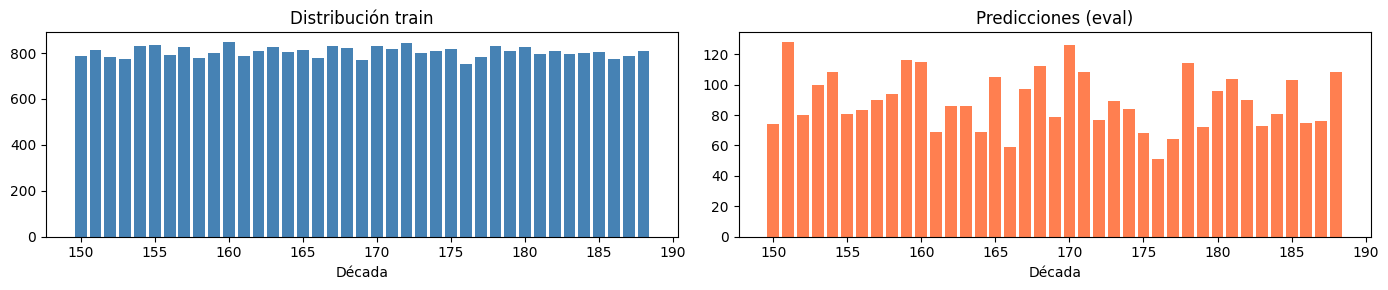

In [36]:
# Distribución de predicciones vs entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

vc_train = pd.Series(y_train).value_counts().sort_index()
vc_pred  = pd.Series(eval_pred).value_counts().sort_index()

axes[0].bar(vc_train.index, vc_train.values, color='steelblue')
axes[0].set_title('Distribución train'); axes[0].set_xlabel('Década')

axes[1].bar(vc_pred.index, vc_pred.values, color='coral')
axes[1].set_title('Predicciones (eval)'); axes[1].set_xlabel('Década')

plt.tight_layout(); plt.show()

## Resumen

| Componente | Detalle |
|---|---|
| **Preprocesamiento** | Colapso de saltos de línea + minúsculas (preserva ortografía histórica) |
| **Features** | `FeatureUnion`: TF-IDF `char` 3–5 gramas (`min_df=5`) + TF-IDF `word` 1–2 gramas (`min_df=3`) |
| **Modelo** | `LogisticRegression(solver='saga')` — mejor calibración en 39 clases con alta superposición |
| **Búsqueda** | `HalvingGridSearchCV`: `C` ∈ {0.1, 1.0, 5.0} |
| **Por qué híbrido** | Char captura ortografía histórica; word captura vocabulario léxico de cada época |
| **Validación** | Hold-out estratificado 15% — acc optimizada en 39 clases |
| **Modelo guardado** | `modelo_parte1.joblib` (joblib) |
| **Submission** | `data/answers.csv` (formato `id,answer`) |